# **ASSESSMENT 1**

In [3]:

import pandas as pd
finance = pd.read_csv(r"/content/finance_economics_dataset.csv")
print(finance)

            Date Stock Index  Open Price  Close Price  Daily High  Daily Low  \
0     2000-01-01   Dow Jones     2128.75      2138.48     2143.70    2100.55   
1     2000-01-02     S&P 500     2046.82      2036.18     2082.83    2009.53   
2     2000-01-03   Dow Jones     1987.92      1985.26     2022.28    1978.37   
3     2000-01-04   Dow Jones     4625.02      4660.47     4665.26    4595.46   
4     2000-01-05     S&P 500     1998.18      1982.18     2044.31    1966.44   
...          ...         ...         ...          ...         ...        ...   
2995  2008-03-14   Dow Jones     1273.76      1235.44     1317.28    1192.34   
2996  2008-03-15     S&P 500     4589.59      4566.91     4607.56    4545.69   
2997  2008-03-16     S&P 500     1477.52      1448.47     1523.86    1402.69   
2998  2008-03-17      NASDAQ     2311.37      2306.90     2346.30    2282.00   
2999  2008-03-18      NASDAQ     4262.98      4303.82     4316.68    4243.04   

      Trading Volume  GDP Growth (%)  I

In [4]:
# What is the shape of the dataset?
print(finance.shape)

(3000, 24)


In [5]:
# What are the column names and their data types?
finance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Date                                   3000 non-null   object 
 1   Stock Index                            3000 non-null   object 
 2   Open Price                             3000 non-null   float64
 3   Close Price                            3000 non-null   float64
 4   Daily High                             3000 non-null   float64
 5   Daily Low                              3000 non-null   float64
 6   Trading Volume                         3000 non-null   int64  
 7   GDP Growth (%)                         3000 non-null   float64
 8   Inflation Rate (%)                     3000 non-null   float64
 9   Unemployment Rate (%)                  3000 non-null   float64
 10  Interest Rate (%)                      3000 non-null   float64
 11  Cons

In [6]:
# How many unique stock indices are there?
unique_indices = finance['Stock Index'].nunique()
print("Number of unique stock indices:", unique_indices)


Number of unique stock indices: 3


In [7]:
# What is the date range of the dataset?
finance['Date'] = pd.to_datetime(finance['Date'])
start_date = finance['Date'].min()
end_date = finance['Date'].max()
print("Date range of the dataset:", start_date, "to", end_date)

Date range of the dataset: 2000-01-01 00:00:00 to 2008-03-18 00:00:00


In [8]:
# Are there any missing values?
missing_values = finance.isnull().sum()
print(missing_values)


Date                                     0
Stock Index                              0
Open Price                               0
Close Price                              0
Daily High                               0
Daily Low                                0
Trading Volume                           0
GDP Growth (%)                           0
Inflation Rate (%)                       0
Unemployment Rate (%)                    0
Interest Rate (%)                        0
Consumer Confidence Index                0
Government Debt (Billion USD)            0
Corporate Profits (Billion USD)          0
Forex USD/EUR                            0
Forex USD/JPY                            0
Crude Oil Price (USD per Barrel)         0
Gold Price (USD per Ounce)               0
Real Estate Index                        0
Retail Sales (Billion USD)               0
Bankruptcy Rate (%)                      0
Mergers & Acquisitions Deals             0
Venture Capital Funding (Billion USD)    0
Consumer Sp

In [9]:
# Are there negative values in columns that should be non-negative?
# Columns that should be non-negative
non_negative_cols = ['Trading Volume','Consumer Confidence Index','Government Debt (Billion USD)',
                     'Corporate Profits (Billion USD)','Crude Oil Price (USD per Barrel)',
                     'Gold Price (USD per Ounce)','Retail Sales (Billion USD)','Venture Capital Funding (Billion USD)',
                     'Consumer Spending (Billion USD)','Stock Index','Open Price','Close Price','Daily High','Daily Low']

# Convert columns to numeric, coerce errors to NaN
for col in non_negative_cols:
    finance[col] = pd.to_numeric(finance[col], errors='coerce')

nan_count = finance[non_negative_cols].isnull().sum()
print("Number of NaN values after conversion:\n", nan_count)

Number of NaN values after conversion:
 Trading Volume                              0
Consumer Confidence Index                   0
Government Debt (Billion USD)               0
Corporate Profits (Billion USD)             0
Crude Oil Price (USD per Barrel)            0
Gold Price (USD per Ounce)                  0
Retail Sales (Billion USD)                  0
Venture Capital Funding (Billion USD)       0
Consumer Spending (Billion USD)             0
Stock Index                              3000
Open Price                                  0
Close Price                                 0
Daily High                                  0
Daily Low                                   0
dtype: int64


In [10]:
# What is the summary of GDP Growth (%)?
gdp_summary = finance['GDP Growth (%)'].describe()
print(gdp_summary)

count    3000.000000
mean        2.608903
std         4.287337
min        -5.000000
25%        -1.012500
50%         2.725000
75%         6.242500
max        10.000000
Name: GDP Growth (%), dtype: float64


In [11]:
# Are there rows with zero or near-zero trading volume?
zero_volume_count = (finance['Trading Volume'] <= 0).sum()
print("Rows with zero or near-zero trading volume:", zero_volume_count)


Rows with zero or near-zero trading volume: 0


In [12]:
# Are there any duplicate rows?
duplicate_count = finance.duplicated().sum()
print("Number of duplicate rows :", duplicate_count)


Number of duplicate rows : 0


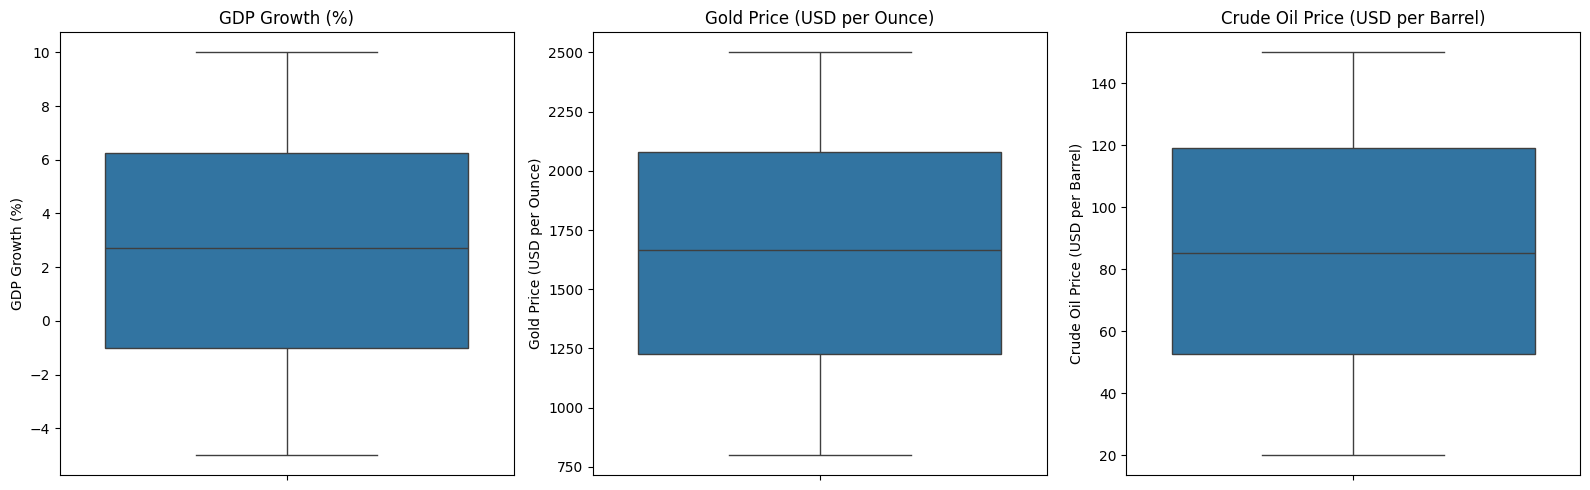

In [13]:
# Are there outliers in GDP, Gold, or Oil prices?
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,5))

# GDP Growth (%)
plt.subplot(1,3,1)
sns.boxplot(y=finance['GDP Growth (%)'])
plt.title("GDP Growth (%)")

# Gold Price
plt.subplot(1,3,2)
sns.boxplot(y=finance['Gold Price (USD per Ounce)'])
plt.title("Gold Price (USD per Ounce)")

# Crude Oil Price
plt.subplot(1,3,3)
sns.boxplot(y=finance['Crude Oil Price (USD per Barrel)'])
plt.title("Crude Oil Price (USD per Barrel)")

plt.tight_layout()
plt.show()

In [14]:
# What is the summary of Inflation Rate (%)?
inflation_summary = finance['Inflation Rate (%)'].describe()
print(inflation_summary)

count    3000.000000
mean        5.096830
std         2.910513
min         0.010000
25%         2.607500
50%         5.110000
75%         7.600000
max        10.000000
Name: Inflation Rate (%), dtype: float64


In [15]:
# What is the average unemployment rate?
avg_unemployment = finance['Unemployment Rate (%)'].mean()
print("Average Unemployment Rate (%):", round(avg_unemployment, 2))

Average Unemployment Rate (%): 8.66


In [16]:
# Which index has the highest trading volume?
# Find the row with the highest trading volume
max_volume_row = finance.loc[finance['Trading Volume'].idxmax()]

# Extract the Stock Index and Trading Volume
stock_index = max_volume_row['Stock Index']
trading_volume = max_volume_row['Trading Volume']

print(f"Stock Index with highest trading volume: {stock_index}")
print(f"Highest Trading Volume: {trading_volume}")

Stock Index with highest trading volume: nan
Highest Trading Volume: 999977078


In [17]:
# How many stock records are from each index?
records_per_index = finance['Stock Index'].value_counts()
print(records_per_index)

Series([], Name: count, dtype: int64)


In [18]:
# What is the correlation between inflation and interest rate?
correlation = finance['Inflation Rate (%)'].corr(finance['Interest Rate (%)'])
print("Correlation between Inflation Rate (%) and Interest Rate (%):", round(correlation, 2))

Correlation between Inflation Rate (%) and Interest Rate (%): 0.01


In [19]:
# What is the average Consumer Confidence Index?
avg_unemployment = finance['Consumer Confidence Index'].mean()
print("Average Unemployment Rate (%):", round(avg_unemployment, 2))

Average Unemployment Rate (%): 85.04


In [20]:
# Which column has the highest standard deviation?
# Calculate standard deviation for numeric columns
std_dev = finance.select_dtypes(include=['float64', 'int64']).std()

# Find the column with the highest standard deviation
max_std_column = std_dev.idxmax()
max_std_value = std_dev.max()

print(f"Column with highest standard deviation: {max_std_column}")
print(f"Standard deviation: {round(max_std_value, 2)}")

Column with highest standard deviation: Trading Volume
Standard deviation: 285900426.37


In [21]:
# What is the highest gold price recorded?
highest_gold_price = finance['Gold Price (USD per Ounce)'].max()
print("Highest Gold Price (USD per Ounce):", highest_gold_price)

Highest Gold Price (USD per Ounce): 2499.66


In [22]:
# Which date had the highest crude oil price?
# Find the row with the highest crude oil price
max_oil_row = finance.loc[finance['Crude Oil Price (USD per Barrel)'].idxmax()]

# Extract the date and price
highest_oil_date = max_oil_row['Date']
highest_oil_price = max_oil_row['Crude Oil Price (USD per Barrel)']

print(f"Date with highest Crude Oil Price: {highest_oil_date}")
print(f"Highest Crude Oil Price (USD per Barrel): {highest_oil_price}")

Date with highest Crude Oil Price: 2001-11-22 00:00:00
Highest Crude Oil Price (USD per Barrel): 149.87


In [23]:
# What is the average corporate profit?
avg_corporate_profit = finance['Corporate Profits (Billion USD)'].mean()
print("Average Corporate Profits (Billion USD):", round(avg_corporate_profit, 2))


Average Corporate Profits (Billion USD): 2553.76


In [24]:
# What percentage of the dataset shows negative GDP growth?
# Count of negative GDP growth
negative_gdp_count = (finance['GDP Growth (%)'] < 0).sum()

# Total number of records
total_records = finance.shape[0]

# Percentage of negative GDP growth
negative_gdp_percent = (negative_gdp_count / total_records) * 100
print(f"Percentage of records with negative GDP growth: {round(negative_gdp_percent, 2)}%")

Percentage of records with negative GDP growth: 31.57%


Correlation between Inflation Rate and Interest Rate: 0.01


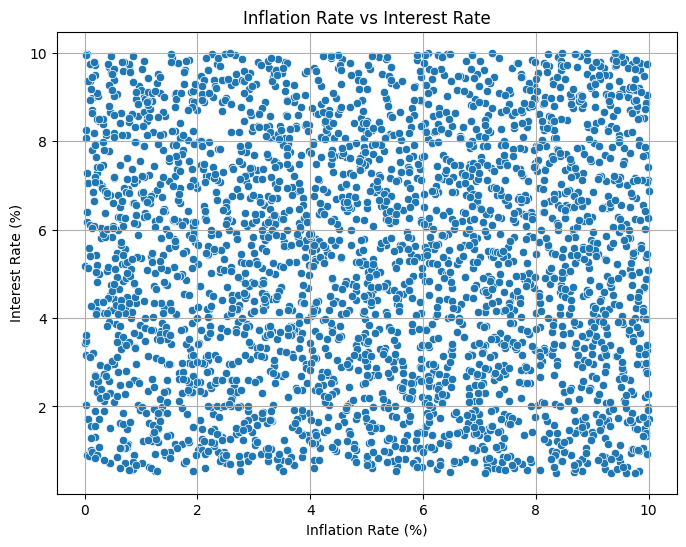

In [25]:
# Does high inflation correspond to higher interest rates?
# Correlation between Inflation Rate and Interest Rate
correlation = finance['Inflation Rate (%)'].corr(finance['Interest Rate (%)'])
print("Correlation between Inflation Rate and Interest Rate:", round(correlation, 2))
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='Inflation Rate (%)', y='Interest Rate (%)', data=finance)
plt.title("Inflation Rate vs Interest Rate")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("Interest Rate (%)")
plt.grid(True)
plt.show()

Correlation between Unemployment Rate and Consumer Spending: 0.02


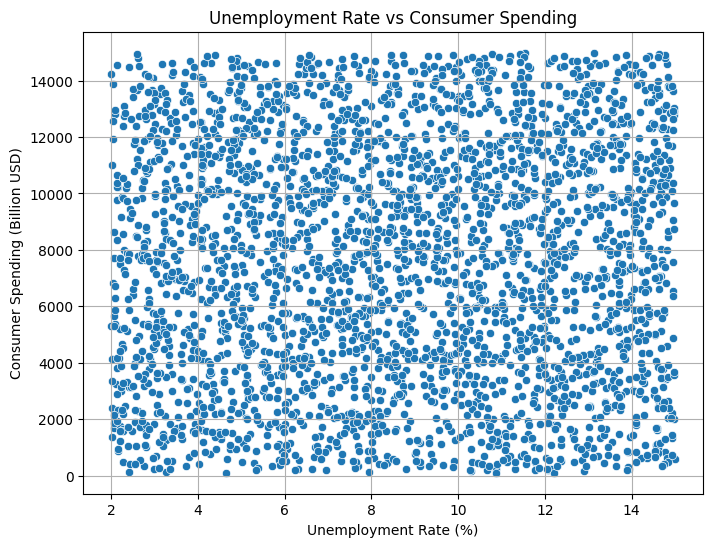

In [26]:
# Is there a relationship between unemployment and consumer spending?
# Correlation between Unemployment Rate and Consumer Spending
correlation = finance['Unemployment Rate (%)'].corr(finance['Consumer Spending (Billion USD)'])
print("Correlation between Unemployment Rate and Consumer Spending:", round(correlation, 2))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='Unemployment Rate (%)', y='Consumer Spending (Billion USD)', data=finance)
plt.title("Unemployment Rate vs Consumer Spending")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Consumer Spending (Billion USD)")
plt.grid(True)
plt.show()

Correlation between Corporate Profits and Consumer Confidence Index: 0.02


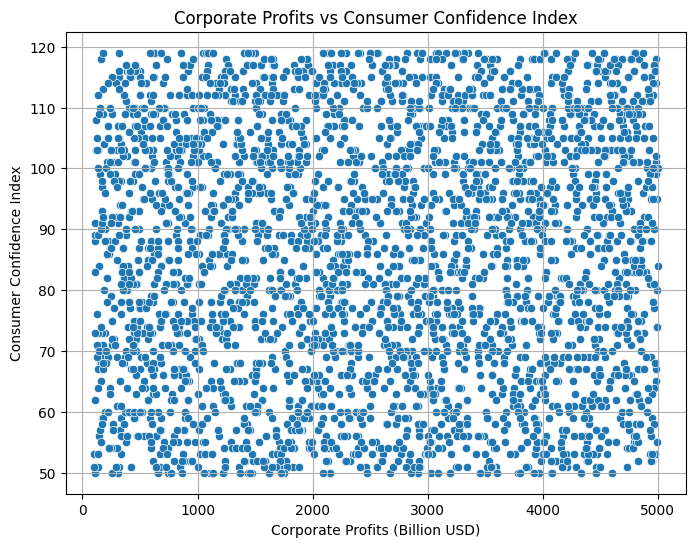

In [27]:
# Do higher corporate profits align with higher consumer confidence?
# Correlation between Corporate Profits and Consumer Confidence Index
correlation = finance['Corporate Profits (Billion USD)'].corr(finance['Consumer Confidence Index'])
print("Correlation between Corporate Profits and Consumer Confidence Index:", round(correlation, 2))
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='Corporate Profits (Billion USD)', y='Consumer Confidence Index', data=finance)
plt.title("Corporate Profits vs Consumer Confidence Index")
plt.xlabel("Corporate Profits (Billion USD)")
plt.ylabel("Consumer Confidence Index")
plt.grid(True)
plt.show()

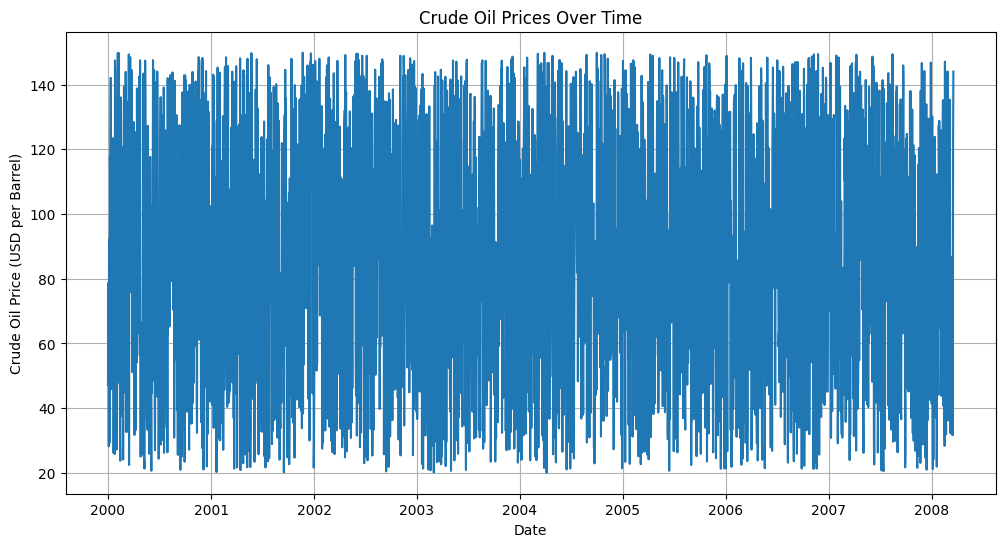

In [28]:
# What’s the trend of crude oil prices over time?
import pandas as pd
import matplotlib.pyplot as plt

# Convert Date column to datetime if not already
finance['Date'] = pd.to_datetime(finance['Date'])

import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='Crude Oil Price (USD per Barrel)', data=finance)
plt.title("Crude Oil Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Crude Oil Price (USD per Barrel)")
plt.grid(True)
plt.show()

Correlation between Gold Price and Stock Close Price: -0.01


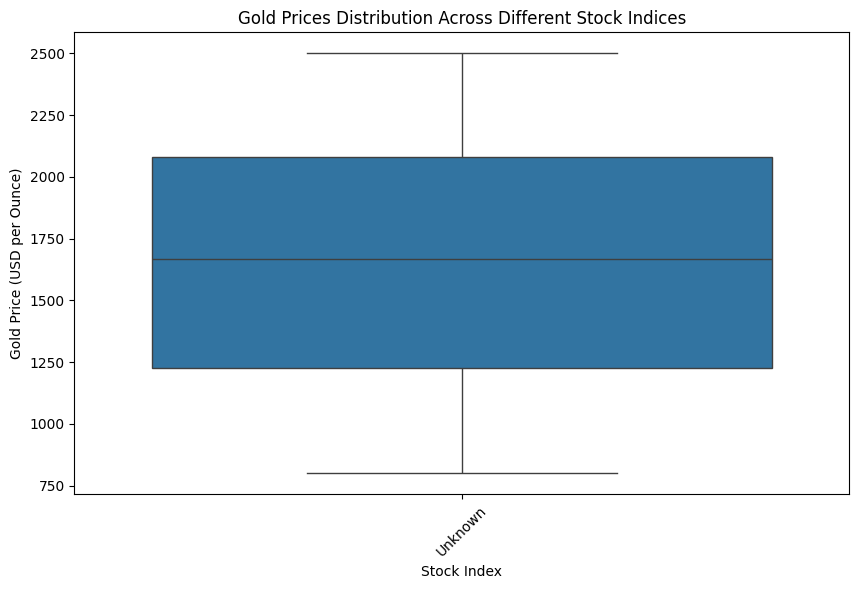

In [31]:
# Are gold prices inversely related to stock performance?
correlation = finance['Gold Price (USD per Ounce)'].corr(finance['Close Price'])
print("Correlation between Gold Price and Stock Close Price:", round(correlation, 2))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
# Fill NaN values in 'Stock Index' with 'Unknown'
# finance['Stock Index'] = finance['Stock Index'].fillna('Unknown')
sns.boxplot(x='Stock Index', y='Gold Price (USD per Ounce)', data=finance)
plt.title("Gold Prices Distribution Across Different Stock Indices")
plt.xticks(rotation=45)
plt.show()

Correlation between Government Debt and Consumer Confidence: -0.04


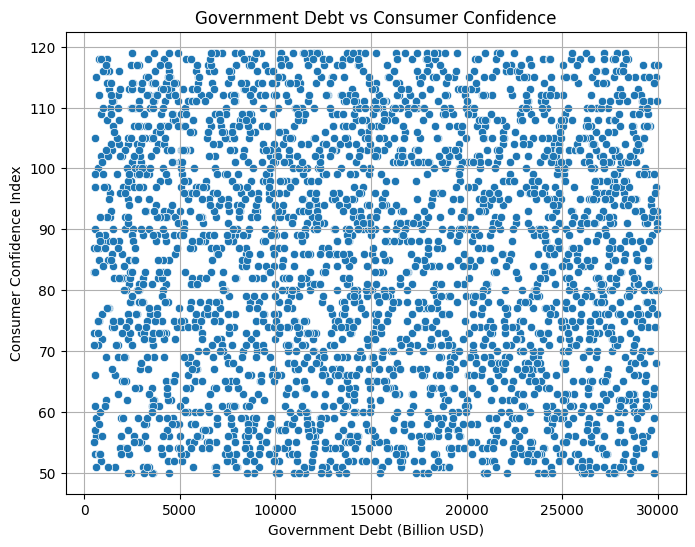

In [32]:
# Does government debt impact consumer confidence?
# Correlation between Government Debt and Consumer Confidence
correlation = finance['Government Debt (Billion USD)'].corr(finance['Consumer Confidence Index'])
print("Correlation between Government Debt and Consumer Confidence:", round(correlation, 2))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(x='Government Debt (Billion USD)', y='Consumer Confidence Index', data=finance)
plt.title("Government Debt vs Consumer Confidence")
plt.xlabel("Government Debt (Billion USD)")
plt.ylabel("Consumer Confidence Index")
plt.grid(True)
plt.show()

Correlation between M&A Activity and Stock Index Closing Price: 0.0


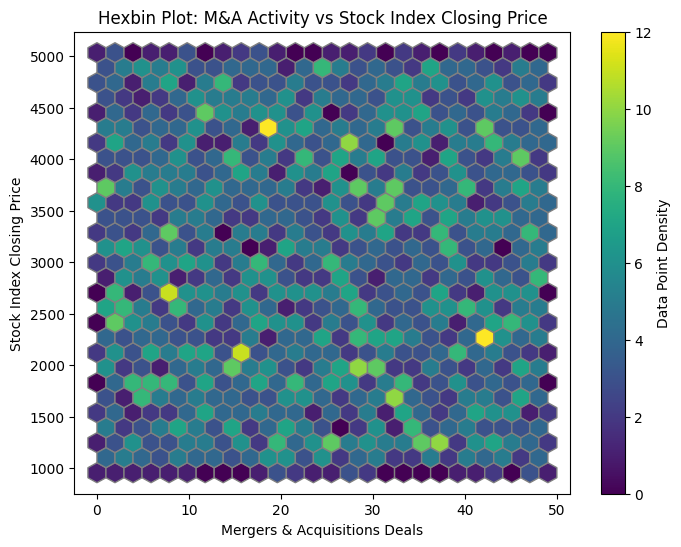

In [33]:
# How do mergers & acquisitions (M&A) activity correlate with stock index closing prices?
# Correlation between M&A Activity and Stock Index Closing Price
correlation = finance['Mergers & Acquisitions Deals'].corr(finance['Close Price'])
print("Correlation between M&A Activity and Stock Index Closing Price:", round(correlation, 2))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.hexbin(
    finance['Mergers & Acquisitions Deals'],
    finance['Close Price'],
    gridsize=25,       # number of hexagons — adjust for detail
    cmap='viridis',    # color scheme
    edgecolors='grey'  # hex border color
)

plt.colorbar(label='Data Point Density')
plt.title('Hexbin Plot: M&A Activity vs Stock Index Closing Price')
plt.xlabel('Mergers & Acquisitions Deals')
plt.ylabel('Stock Index Closing Price')
plt.show()

Correlation between Retail Sales and GDP Growth (%): -0.01


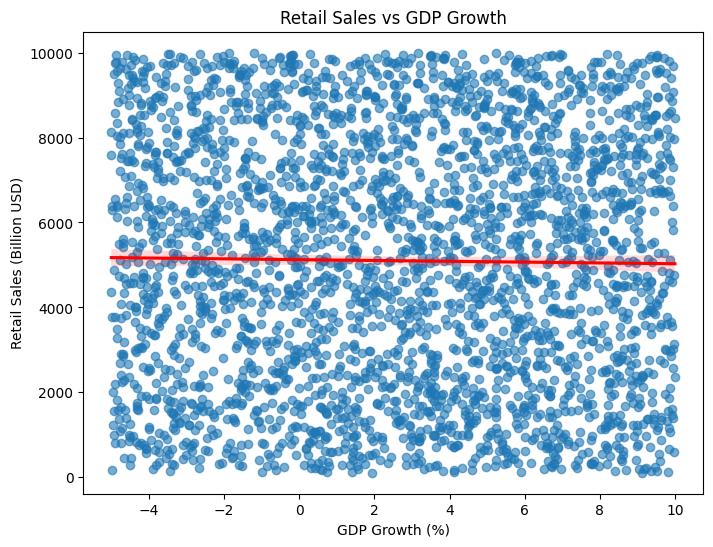

In [34]:
# Is retail sales growth associated with GDP growth?
correlation = finance['Retail Sales (Billion USD)'].corr(finance['GDP Growth (%)'])
print("Correlation between Retail Sales and GDP Growth (%):", round(correlation, 2))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.regplot(
    x='GDP Growth (%)',
    y='Retail Sales (Billion USD)',
    data=finance,
    scatter_kws={'alpha':0.6},   # slightly transparent points
    line_kws={'color':'red'}     # regression line
)
plt.title('Retail Sales vs GDP Growth')
plt.xlabel('GDP Growth (%)')
plt.ylabel('Retail Sales (Billion USD)')
plt.show()

Correlation between Stock Market (Close Price) and Consumer Spending: 0.0


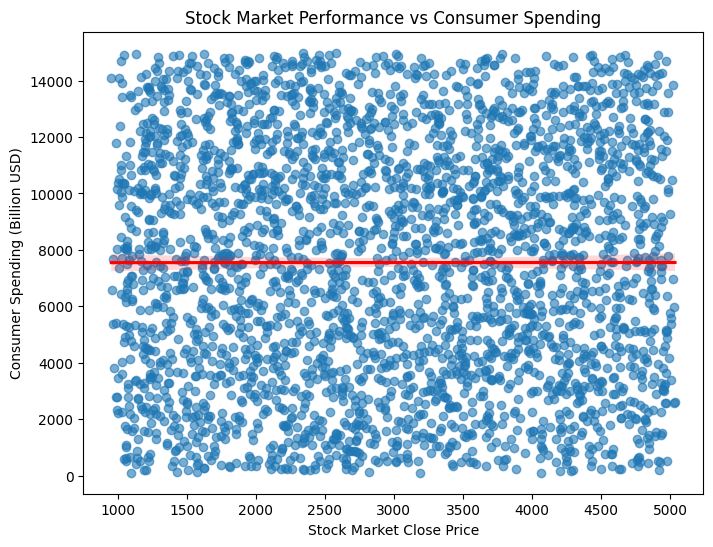

In [35]:
# Is stock market performance linked to consumer spending?
correlation = finance['Close Price'].corr(finance['Consumer Spending (Billion USD)'])
print("Correlation between Stock Market (Close Price) and Consumer Spending:", round(correlation, 2))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.regplot(
    x='Close Price',
    y='Consumer Spending (Billion USD)',
    data=finance,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)
plt.title('Stock Market Performance vs Consumer Spending')
plt.xlabel('Stock Market Close Price')
plt.ylabel('Consumer Spending (Billion USD)')
plt.show()

In [36]:
# Which stock index had the highest average closing price?
# Group by Stock Index and calculate average closing price
highest_avg_close = finance.groupby('Stock Index')['Close Price'].mean().sort_values(ascending=False)

# Display result
print(highest_avg_close)

# Display the top 1 index
top_index = highest_avg_close.idxmax()
top_value = highest_avg_close.max()
print(f"\nStock Index with Highest Average Closing Price: {top_index} (${top_value:.2f})")

Stock Index
Unknown    2981.249173
Name: Close Price, dtype: float64

Stock Index with Highest Average Closing Price: Unknown ($2981.25)


Correlation between Interest Rate and Unemployment Rate: 0.02


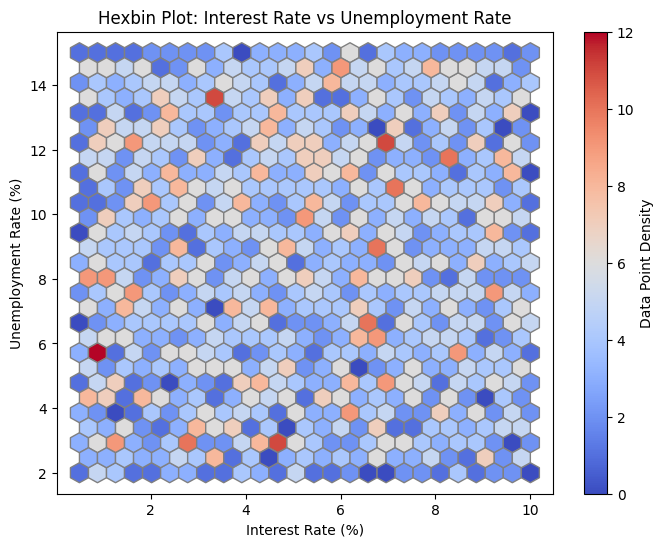

In [37]:
# What is the relationship between interest rate and unemployment?
# Calculate correlation between Interest Rate (%) and Unemployment Rate (%)
correlation = finance['Interest Rate (%)'].corr(finance['Unemployment Rate (%)'])
print("Correlation between Interest Rate and Unemployment Rate:", round(correlation, 2))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.hexbin(
    finance['Interest Rate (%)'],
    finance['Unemployment Rate (%)'],
    gridsize=25,     # number of hexagons
    cmap='coolwarm', # color map
    edgecolors='grey'
)
plt.colorbar(label='Data Point Density')
plt.title('Hexbin Plot: Interest Rate vs Unemployment Rate')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.show()

Correlation between Consumer Confidence and Bankruptcy Rate: -0.02


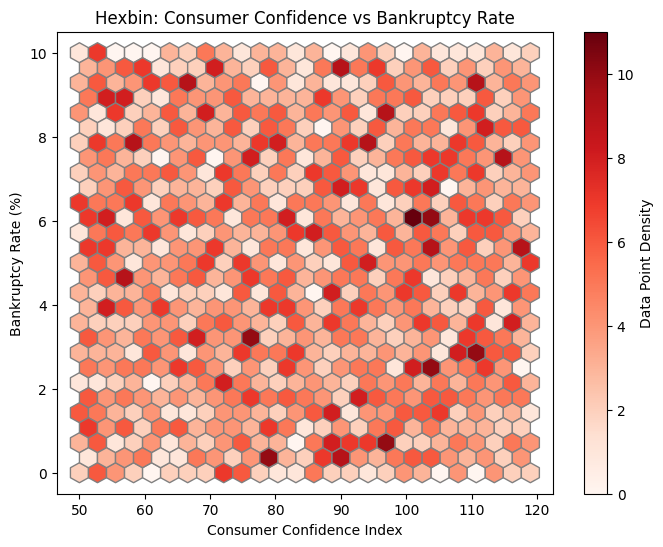

In [38]:
# Do lower consumer confidence values coincide with higher bankruptcy rates?
# Correlation between Consumer Confidence Index and Bankruptcy Rate (%)
correlation = finance['Consumer Confidence Index'].corr(finance['Bankruptcy Rate (%)'])
print("Correlation between Consumer Confidence and Bankruptcy Rate:", round(correlation, 2))

plt.figure(figsize=(8,6))
plt.hexbin(
    finance['Consumer Confidence Index'],
    finance['Bankruptcy Rate (%)'],
    gridsize=25,
    cmap='Reds',
    edgecolors='grey'
)
plt.colorbar(label='Data Point Density')
plt.title('Hexbin: Consumer Confidence vs Bankruptcy Rate')
plt.xlabel('Consumer Confidence Index')
plt.ylabel('Bankruptcy Rate (%)')
plt.show()

Close Price                              1.000000
Daily High                               0.999821
Daily Low                                0.999820
Open Price                               0.999688
Retail Sales (Billion USD)               0.049370
Bankruptcy Rate (%)                      0.029380
Venture Capital Funding (Billion USD)    0.021414
Interest Rate (%)                        0.020434
Trading Volume                           0.016283
Consumer Confidence Index                0.013482
Corporate Profits (Billion USD)          0.008797
Mergers & Acquisitions Deals             0.002637
Crude Oil Price (USD per Barrel)         0.002563
Consumer Spending (Billion USD)          0.000376
Unemployment Rate (%)                   -0.001907
Government Debt (Billion USD)           -0.007332
Inflation Rate (%)                      -0.007972
Real Estate Index                       -0.008639
GDP Growth (%)                          -0.012748
Gold Price (USD per Ounce)              -0.014544


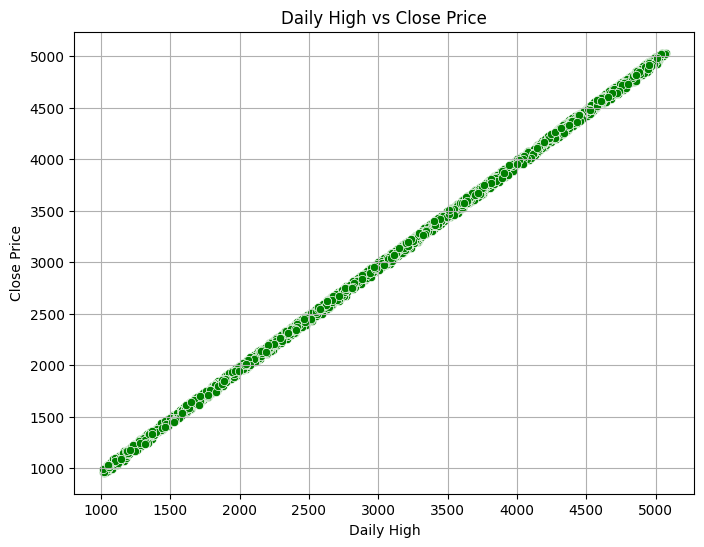

In [39]:
# Which indicator has the highest correlation with stock close price?
# Select only numeric columns
numeric_cols = finance.select_dtypes(include='number').columns

# Compute correlation of each numeric column with Close Price
correlations = finance[numeric_cols].corr()['Close Price'].sort_values(ascending=False)

# Display all correlations
print(correlations)

# Exclude correlation of Close Price with itself
highest_corr = correlations.drop('Close Price').idxmax()
highest_value = correlations.drop('Close Price').max()

print(f"Indicator with highest correlation to Close Price: {highest_corr} ({highest_value:.2f})")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=finance[highest_corr],
    y=finance['Close Price'],
    color='green'
)
plt.title(f'{highest_corr} vs Close Price')
plt.xlabel(highest_corr)
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

Correlation between Corporate Profits and Unemployment Rate: 0.01


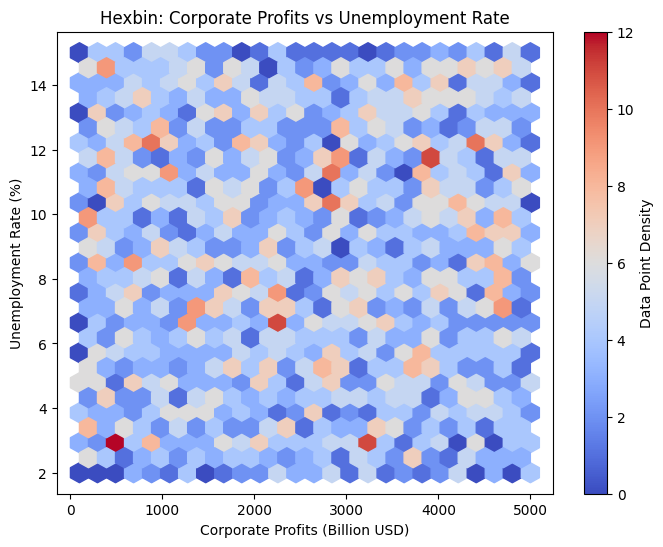

In [40]:
# Are unemployment rates lower when corporate profits are high?
# Correlation between Corporate Profits and Unemployment Rate
correlation = finance['Corporate Profits (Billion USD)'].corr(finance['Unemployment Rate (%)'])
print("Correlation between Corporate Profits and Unemployment Rate:", round(correlation, 2))

plt.figure(figsize=(8,6))
plt.hexbin(
    finance['Corporate Profits (Billion USD)'],
    finance['Unemployment Rate (%)'],
    gridsize=25,
    cmap='coolwarm'
)
plt.colorbar(label='Data Point Density')
plt.title('Hexbin: Corporate Profits vs Unemployment Rate')
plt.xlabel('Corporate Profits (Billion USD)')
plt.ylabel('Unemployment Rate (%)')
plt.show()

## **ASSESSMENT 2**

In [41]:
import pandas as pd
sales = pd.read_csv(r"/content/Retail Data.csv")
print(sales)

     Order No  Order Date           Customer Name  \
0      4293-1  02-09-2014        Vivek Sundaresam   
1      5001-1  24-10-2015          Shahid Hopkins   
2      5004-1  13-03-2014           Dennis Pardue   
3      5009-1  18-02-2013              Sean Wendt   
4      5010-1  13-09-2014  Christina Vanderzanden   
...       ...         ...                     ...   
4995   6831-1  02-11-2016           Roland Murray   
4996   6847-1  16-12-2015          Patrick OBrill   
4997   6922-1  28-09-2016            Troy Staebel   
4998   6939-1  18-06-2016             Shaun Weien   
4999   6980-1  12-08-2015          Nora Pelletier   

                                  Address       City State   Customer Type  \
0          152 Bunnerong Road,Eastgardens     Sydney   NSW  Small Business   
1           438 Victoria Avenue,Chatswood     Sydney   NSW       Corporate   
2                412 Brunswick St,Fitzroy  Melbourne   VIC        Consumer   
3                145 Ramsay St,Haberfield     Sydne

In [42]:
# View the structure of the dataset (columns, types, missing values).
print(sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order No           5000 non-null   object 
 1   Order Date         5000 non-null   object 
 2   Customer Name      5000 non-null   object 
 3   Address            4999 non-null   object 
 4   City               5000 non-null   object 
 5   State              5000 non-null   object 
 6   Customer Type      5000 non-null   object 
 7   Account Manager    5000 non-null   object 
 8   Order Priority     5000 non-null   object 
 9   Product Name       5000 non-null   object 
 10  Product Category   5000 non-null   object 
 11  Product Container  5000 non-null   object 
 12  Ship Mode          5000 non-null   object 
 13  Ship Date          5000 non-null   object 
 14  Cost Price         5000 non-null   object 
 15  Retail Price       5000 non-null   object 
 16  Profit Margin      5000 

In [43]:
# What is the shape (rows, columns) of the dataset?
print(sales.shape)

(5000, 24)


In [44]:
# Are there any duplicate records?\
duplicates = sales.duplicated().sum()
print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


In [45]:
# Are there any missing or corrupted entries in Ship Date, Order Date, or numeric columns?

missing_values = sales[['Order Date']].isnull().sum()
print("Missing values in Order Date:\n", missing_values)

# If Ship Date column exists, include it
if 'Ship Date' in sales.columns:
    print("\nMissing values in Ship Date:\n", sales['Ship Date'].isnull().sum())

# Check numeric columns for missing or corrupted entries
numeric_cols = sales.select_dtypes(include=['number']).columns
print("\nMissing values in numeric columns:\n", sales[numeric_cols].isnull().sum())

Missing values in Order Date:
 Order Date    0
dtype: int64

Missing values in Ship Date:
 0

Missing values in numeric columns:
 Order Quantity    1
dtype: int64


In [46]:
# Convert Order Date and Ship Date to datetime.
# Convert Order Date and Ship Date to datetime format
sales['Order Date'] = pd.to_datetime(sales['Order Date'], errors='coerce')

# Check if Ship Date column exists before converting
if 'Ship Date' in sales.columns:
    sales['Ship Date'] = pd.to_datetime(sales['Ship Date'], errors='coerce')

# Verify conversion
print(sales[['Order Date']].head())

if 'Ship Date' in sales.columns:
    print(sales[['Ship Date']].head())

  Order Date
0 2014-02-09
1        NaT
2        NaT
3        NaT
4        NaT
   Ship Date
0 2014-04-09
1        NaT
2        NaT
3        NaT
4        NaT


In [47]:
# Check for future or inconsistent shipping dates.
import pandas as pd

# Ensure both columns are in datetime format
sales['Order Date'] = pd.to_datetime(sales['Order Date'], errors='coerce')
if 'Ship Date' in sales.columns:
    sales['Ship Date'] = pd.to_datetime(sales['Ship Date'], errors='coerce')

# 1️ Check for shipping dates in the future
future_ship_dates = sales[sales['Ship Date'] > pd.Timestamp.today()]

# 2️ Check for inconsistent shipping dates (Ship Date before Order Date)
inconsistent_dates = sales[sales['Ship Date'] < sales['Order Date']]

# Display the results
print("Future Ship Dates:")
print(future_ship_dates[['Order Date', 'Ship Date']])

print("\n Inconsistent Ship Dates (Ship Date before Order Date):")
print(inconsistent_dates[['Order Date', 'Ship Date']])

Future Ship Dates:
Empty DataFrame
Columns: [Order Date, Ship Date]
Index: []

 Inconsistent Ship Dates (Ship Date before Order Date):
     Order Date  Ship Date
204  2014-04-09 2014-03-09
764  2014-07-10 2014-02-10
765  2014-06-10 2014-02-10
863  2014-04-10 2014-02-10
1292 2014-12-02 2014-11-02
1322 2013-09-08 2013-03-09
1421 2015-04-12 2015-03-12
1513 2014-03-04 2014-02-04
1514 2014-03-04 2014-02-04
1594 2015-03-03 2015-01-03
1963 2014-09-08 2013-10-08
2057 2015-03-02 2015-02-03
2098 2015-03-02 2015-02-03
2316 2014-12-08 2014-10-08
2450 2015-03-02 2015-02-03
2761 2015-11-09 2015-02-09
2841 2015-03-02 2015-02-03
2926 2015-03-03 2015-01-03
3240 2016-08-11 2016-02-11
3325 2016-03-02 2016-02-03
3897 2016-03-11 2016-02-11
4168 2017-07-02 2017-04-02
4376 2015-03-05 2015-02-05
4685 2016-09-11 2016-03-11


In [48]:
# Convert price columns to numeric (remove $ and commas).
import pandas as pd

# List of price-related columns
price_columns = [
    'Cost Price', 'Retail Price', 'Profit Margin',
    'Sub Total', 'Discount $', 'Order Total', 'Shipping Cost', 'Total'
]

# Remove $ and commas, then convert to numeric
for col in price_columns:
    if col in sales.columns:
        sales[col] = sales[col].replace('[\$,]', '', regex=True).astype(float)

#  Check result
print(sales[price_columns].head())
print("\nData types after conversion:\n", sales[price_columns].dtypes)

   Cost Price  Retail Price  Profit Margin  Sub Total  Discount $  \
0      156.50        300.97         144.47    4533.52      194.83   
1        0.24          1.26           1.02      45.20        0.00   
2       42.11         80.98          38.87     873.32       72.23   
3        5.33          8.60           3.27      73.52        4.35   
4        1.53          2.78           1.25     138.46        5.95   

   Order Total  Shipping Cost    Total  
0      4757.22           7.18  4291.55  
1        45.90           0.70    46.91  
2       837.57           7.18    82.58  
3       740.67           6.19   730.92  
4       123.77           1.34   125.97  

Data types after conversion:
 Cost Price       float64
Retail Price     float64
Profit Margin    float64
Sub Total        float64
Discount $       float64
Order Total      float64
Shipping Cost    float64
Total            float64
dtype: object


<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:13: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-4254791431.py:13: SyntaxWarning: invalid escape sequence '\$'
  sales[col] = sales[col].replace('[\$,]', '', regex=True).astype(float)


In [49]:
# What are the unique values in Customer Type and Order Priority?
# Unique values in 'Customer Type' and 'Order Priority'
print("Unique Customer Types:\n", sales['Customer Type'].unique())
print("\nUnique Order Priorities:\n", sales['Order Priority'].unique())

Unique Customer Types:
 ['Small Business' 'Corporate' 'Consumer' 'Home Office']

Unique Order Priorities:
 ['Critical' 'Medium' 'Not Specified' 'Low' 'High']


In [50]:
# What are the most common shipping modes?
# Check if 'Ship Mode' column exists
if 'Ship Mode' in sales.columns:
    # Count frequency of each shipping mode
    shipping_counts = sales['Ship Mode'].value_counts()
    print("Most common shipping modes:\n", shipping_counts)
else:
    print("The dataset does not have a 'Ship Mode' column.")

Most common shipping modes:
 Ship Mode
Regular Air       4236
Express Air        647
Delivery Truck     117
Name: count, dtype: int64


In [51]:
# Which cities have the highest number of orders?
# Count orders per city
city_counts = sales['City'].value_counts()

# Display top 10 cities with most orders
print("Top 10 cities with highest number of orders:\n", city_counts.head(10))

Top 10 cities with highest number of orders:
 City
Sydney       3584
Melbourne    1416
Name: count, dtype: int64


In [52]:
# What’s the range of order quantities and prices?
# Ensure numeric columns are converted
sales['Order Quantity'] = pd.to_numeric(sales['Order Quantity'], errors='coerce')

# Price columns (already converted to numeric in step 7)
price_columns = ['Cost Price', 'Retail Price', 'Profit Margin', 'Sub Total', 'Discount $', 'Order Total', 'Shipping Cost', 'Total']

# 1️ Range of Order Quantity
order_qty_min = sales['Order Quantity'].min()
order_qty_max = sales['Order Quantity'].max()
print(f"Order Quantity range: {order_qty_min} to {order_qty_max}")

# 2️ Range of price columns
for col in price_columns:
    if col in sales.columns:
        col_min = sales[col].min()
        col_max = sales[col].max()
        print(f"{col} range: {col_min} to {col_max}")

Order Quantity range: 1.0 to 50.0
Cost Price range: 0.24 to 377.99
Retail Price range: 1.14 to 599.99
Profit Margin range: 0.36 to 430.18
Sub Total range: 1.88 to 31699.82
Discount $ range: 0.0 to 6094.9
Order Total range: 1.71 to 28299.51
Shipping Cost range: 0.49 to 69.3
Total range: 2.85 to 26725.06


In [53]:
# Create a new column for shipping duration.
# Ensure both columns are in datetime format
sales['Order Date'] = pd.to_datetime(sales['Order Date'], errors='coerce')
if 'Ship Date' in sales.columns:
    sales['Ship Date'] = pd.to_datetime(sales['Ship Date'], errors='coerce')

# Create new column 'Shipping Duration' in days
sales['Shipping Duration'] = (sales['Ship Date'] - sales['Order Date']).dt.days

# Display first few rows to check
print(sales[['Order Date', 'Ship Date', 'Shipping Duration']].head())

  Order Date  Ship Date  Shipping Duration
0 2014-02-09 2014-04-09               59.0
1        NaT        NaT                NaN
2        NaT        NaT                NaN
3        NaT        NaT                NaN
4        NaT        NaT                NaN


In [54]:
# Are there any orders with zero or negative total or quantity?
# Ensure numeric columns are properly converted
sales['Order Quantity'] = pd.to_numeric(sales['Order Quantity'], errors='coerce')
sales['Total'] = pd.to_numeric(sales['Total'], errors='coerce')

# Find orders with zero or negative quantity
invalid_quantity = sales[sales['Order Quantity'] <= 0]

# Find orders with zero or negative total
invalid_total = sales[sales['Total'] <= 0]

# Display results
print("Orders with zero or negative quantity:\n", invalid_quantity[['Order No', 'Order Quantity', 'Total']])
print("\nOrders with zero or negative total:\n", invalid_total[['Order No', 'Order Quantity', 'Total']])

Orders with zero or negative quantity:
 Empty DataFrame
Columns: [Order No, Order Quantity, Total]
Index: []

Orders with zero or negative total:
 Empty DataFrame
Columns: [Order No, Order Quantity, Total]
Index: []


In [55]:
# Are all discount percentages matching discount dollar amounts?
# Ensure numeric columns
sales['Sub Total'] = pd.to_numeric(sales['Sub Total'], errors='coerce')
sales['Discount $'] = pd.to_numeric(sales['Discount $'], errors='coerce')
sales['Discount %'] = pd.to_numeric(sales['Discount %'], errors='coerce')  # convert if not already numeric

# Calculate expected discount in dollars
sales['Expected Discount $'] = (sales['Sub Total'] * sales['Discount %']) / 100

# Check for mismatches (allowing small rounding tolerance)
mismatch = sales[abs(sales['Discount $'] - sales['Expected Discount $']) > 0.01]

print("Number of mismatched discount records:", len(mismatch))
print(mismatch[['Order No', 'Sub Total', 'Discount %', 'Discount $', 'Expected Discount $']].head())

Number of mismatched discount records: 0
Empty DataFrame
Columns: [Order No, Sub Total, Discount %, Discount $, Expected Discount $]
Index: []


In [56]:
# Check for mismatches in total calculation’
# Ensure numeric columns
sales['Sub Total'] = pd.to_numeric(sales['Sub Total'], errors='coerce')
sales['Discount $'] = pd.to_numeric(sales['Discount $'], errors='coerce')
sales['Shipping Cost'] = pd.to_numeric(sales['Shipping Cost'], errors='coerce')
sales['Total'] = pd.to_numeric(sales['Total'], errors='coerce')

# Calculate expected total
sales['Expected Total'] = sales['Sub Total'] - sales['Discount $'] + sales['Shipping Cost']

# Find mismatches (allowing small tolerance for rounding)
total_mismatch = sales[abs(sales['Total'] - sales['Expected Total']) > 0.01]

print("Number of orders with total mismatch:", len(total_mismatch))
print(total_mismatch[['Order No', 'Sub Total', 'Discount $', 'Shipping Cost', 'Total', 'Expected Total']].head())

Number of orders with total mismatch: 3960
  Order No  Sub Total  Discount $  Shipping Cost    Total  Expected Total
0   4293-1    4533.52      194.83           7.18  4291.55         4345.87
1   5001-1      45.20        0.00           0.70    46.91           45.90
2   5004-1     873.32       72.23           7.18    82.58          808.27
3   5009-1      73.52        4.35           6.19   730.92           75.36
4   5010-1     138.46        5.95           1.34   125.97          133.85


In [57]:
# Identify top 5 products by order quantity.
# Ensure Order Quantity is numeric
sales['Order Quantity'] = pd.to_numeric(sales['Order Quantity'], errors='coerce')

# Group by Product Name and sum the quantities
product_quantity = sales.groupby('Product Name')['Order Quantity'].sum()

# Sort in descending order and get top 5
top_products = product_quantity.sort_values(ascending=False).head(5)

print("Top 5 products by order quantity:\n", top_products)

Top 5 products by order quantity:
 Product Name
Artisan 474 Labels                         3395.0
Smiths General Use 3-Ring Binders          3220.0
Artisan 479 Labels                         3039.0
Artisan 481 Labels                         2996.0
Apex Preferred Stainless Steel Scissors    2896.0
Name: Order Quantity, dtype: float64


In [58]:
# Which Account Manager handled the most revenue?
# Ensure Total is numeric
sales['Total'] = pd.to_numeric(sales['Total'], errors='coerce')

# Group by Account Manager and sum Total
manager_revenue = sales.groupby('Account Manager')['Total'].sum()

# Sort in descending order to find the highest revenue
top_manager = manager_revenue.sort_values(ascending=False).head(1)

print("Account Manager with highest revenue:\n", top_manager)

Account Manager with highest revenue:
 Account Manager
Connor Betts    671173.17
Name: Total, dtype: float64


In [59]:
# What is the average shipping cost by mode?
# Ensure Shipping Cost is numeric
sales['Shipping Cost'] = pd.to_numeric(sales['Shipping Cost'], errors='coerce')

# Check if 'Ship Mode' exists
if 'Ship Mode' in sales.columns:
    avg_shipping = sales.groupby('Ship Mode')['Shipping Cost'].mean().sort_values(ascending=False)
    print("Average shipping cost by mode:\n", avg_shipping)
else:
    print("The dataset does not have a 'Ship Mode' column.")

Average shipping cost by mode:
 Ship Mode
Regular Air       5.503553
Delivery Truck    5.270085
Express Air       5.247311
Name: Shipping Cost, dtype: float64


In [60]:
# Find the most profitable product.

# Ensure Profit Margin is numeric
sales['Profit Margin'] = pd.to_numeric(sales['Profit Margin'], errors='coerce')

# Group by Product Name and sum the profit
product_profit = sales.groupby('Product Name')['Profit Margin'].sum()

# Find the most profitable product
most_profitable_product = product_profit.sort_values(ascending=False).head(1)

print("Most profitable product:\n", most_profitable_product)

Most profitable product:
 Product Name
Cando PC940 Copier    17585.76
Name: Profit Margin, dtype: float64


In [61]:
# What is the total revenue generated across all orders?
# Ensure Total is numeric
sales['Total'] = pd.to_numeric(sales['Total'], errors='coerce')

# Calculate total revenue
total_revenue = sales['Total'].sum()

print(f"Total revenue generated across all orders: ${total_revenue:,.2f}")

Total revenue generated across all orders: $3,731,536.40


In [62]:
# Which customer type generates more revenue?
# Ensure Total is numeric
sales['Total'] = pd.to_numeric(sales['Total'], errors='coerce')

# Group by Customer Type and sum revenue
customer_revenue = sales.groupby('Customer Type')['Total'].sum().sort_values(ascending=False)

print("Revenue by Customer Type:\n", customer_revenue)
print("\nCustomer type generating the most revenue:", customer_revenue.idxmax())

Revenue by Customer Type:
 Customer Type
Corporate         1373796.44
Home Office        851621.96
Small Business     830886.35
Consumer           675231.65
Name: Total, dtype: float64

Customer type generating the most revenue: Corporate


In [63]:
# How does order priority affect revenue?
# Ensure Total is numeric
sales['Total'] = pd.to_numeric(sales['Total'], errors='coerce')

# Group by Order Priority and sum revenue
priority_revenue = sales.groupby('Order Priority')['Total'].sum().sort_values(ascending=False)

print("Revenue by Order Priority:\n", priority_revenue)

Revenue by Order Priority:
 Order Priority
Not Specified    817844.66
High             794199.00
Medium           784744.63
Critical         694547.97
Low              640200.14
Name: Total, dtype: float64


In [64]:
# What is the average profit margin by product category?
# Ensure Profit Margin is numeric
sales['Profit Margin'] = pd.to_numeric(sales['Profit Margin'], errors='coerce')

# Check if 'Product Category' exists
if 'Product Category' in sales.columns:
    avg_profit_by_category = sales.groupby('Product Category')['Profit Margin'].mean().sort_values(ascending=False)
    print("Average profit margin by product category:\n", avg_profit_by_category)
else:
    print("The dataset does not have a 'Product Category' column.")


Average profit margin by product category:
 Product Category
Technology         20.423208
Office Supplies    17.682609
Furniture          12.701953
Name: Profit Margin, dtype: float64


In [65]:
# What is the most profitable product overall?
# Ensure Profit Margin is numeric
sales['Profit Margin'] = pd.to_numeric(sales['Profit Margin'], errors='coerce')

# Group by Product Name and sum the profit
product_profit = sales.groupby('Product Name')['Profit Margin'].sum()

# Find the most profitable product
most_profitable_product = product_profit.sort_values(ascending=False).head(1)

print("Most profitable product overall:\n", most_profitable_product)

Most profitable product overall:
 Product Name
Cando PC940 Copier    17585.76
Name: Profit Margin, dtype: float64


In [66]:
# How many days does it usually take to ship an order?
# Ensure Shipping Duration column exists
if 'Shipping Duration' not in sales.columns:
    # Create it if not already created
    sales['Order Date'] = pd.to_datetime(sales['Order Date'], errors='coerce')
    sales['Ship Date'] = pd.to_datetime(sales['Ship Date'], errors='coerce')
    sales['Shipping Duration'] = (sales['Ship Date'] - sales['Order Date']).dt.days

# Calculate average shipping duration
avg_shipping_days = sales['Shipping Duration'].mean()
print(f"Average number of days to ship an order: {avg_shipping_days:.2f} days")

Average number of days to ship an order: 50.47 days


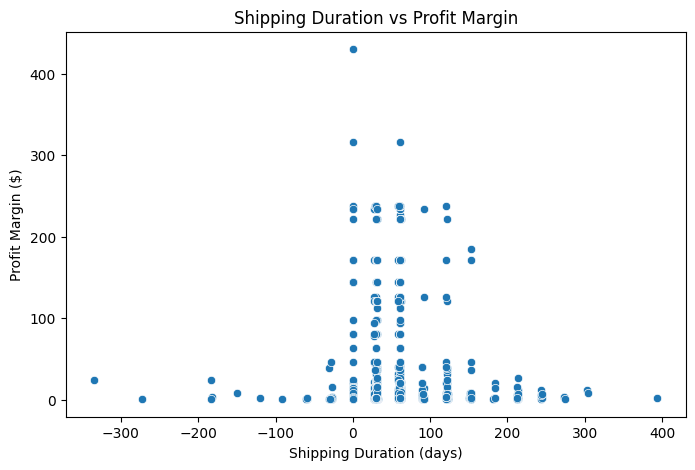

Correlation between Shipping Duration and Profit Margin: -0.03


In [67]:
# Do longer shipping times impact profit margins?
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure numeric columns
sales['Profit Margin'] = pd.to_numeric(sales['Profit Margin'], errors='coerce')
sales['Shipping Duration'] = pd.to_numeric(sales['Shipping Duration'], errors='coerce')

# Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='Shipping Duration', y='Profit Margin', data=sales)
plt.title("Shipping Duration vs Profit Margin")
plt.xlabel("Shipping Duration (days)")
plt.ylabel("Profit Margin ($)")
plt.show()

# Calculate correlation
correlation = sales['Shipping Duration'].corr(sales['Profit Margin'])
print(f"Correlation between Shipping Duration and Profit Margin: {correlation:.2f}")

In [68]:
# Which city brings in the highest revenue?
# Ensure Total is numeric
sales['Total'] = pd.to_numeric(sales['Total'], errors='coerce')

# Group by City and sum Total revenue
city_revenue = sales.groupby('City')['Total'].sum().sort_values(ascending=False)

# Top city
top_city = city_revenue.head(1)

print("City generating the highest revenue:\n", top_city)

City generating the highest revenue:
 City
Sydney    2678780.33
Name: Total, dtype: float64


In [69]:
# Which account manager generated the most revenue?
# Ensure Total is numeric
sales['Total'] = pd.to_numeric(sales['Total'], errors='coerce')

# Group by Account Manager and sum revenue
manager_revenue = sales.groupby('Account Manager')['Total'].sum().sort_values(ascending=False)

# Top Account Manager
top_manager = manager_revenue.head(1)

print("Account Manager generating the most revenue:\n", top_manager)

Account Manager generating the most revenue:
 Account Manager
Connor Betts    671173.17
Name: Total, dtype: float64


Most cost-effective shipping mode:
 Ship Mode
Express Air    5.247311
Name: Shipping Cost, dtype: float64


Text(0.5, 1.0, 'Correlation Heatmap')

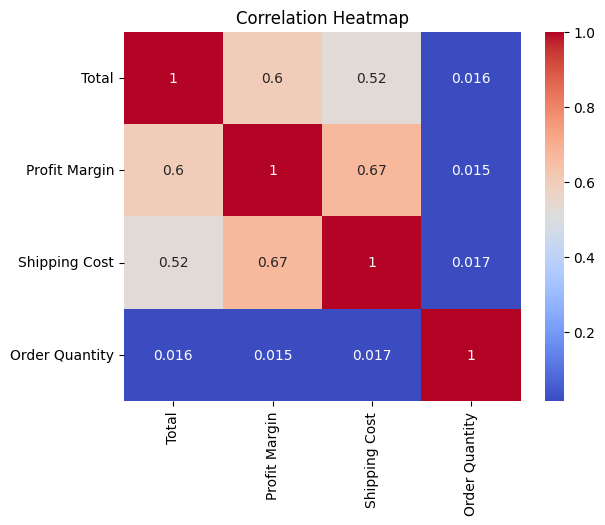

In [70]:
# Which shipping mode is most cost-effective (lowest avg. shipping)?
# Ensure Shipping Cost is numeric
sales['Shipping Cost'] = pd.to_numeric(sales['Shipping Cost'], errors='coerce')

# Group by Ship Mode and calculate average shipping cost
avg_shipping_cost = sales.groupby('Ship Mode')['Shipping Cost'].mean().sort_values()

# Most cost-effective shipping mode (lowest average cost)
most_cost_effective = avg_shipping_cost.head(1)

print("Most cost-effective shipping mode:\n", most_cost_effective)

numeric_cols = ['Total','Profit Margin','Shipping Cost','Order Quantity']
sns.heatmap(sales[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

float64


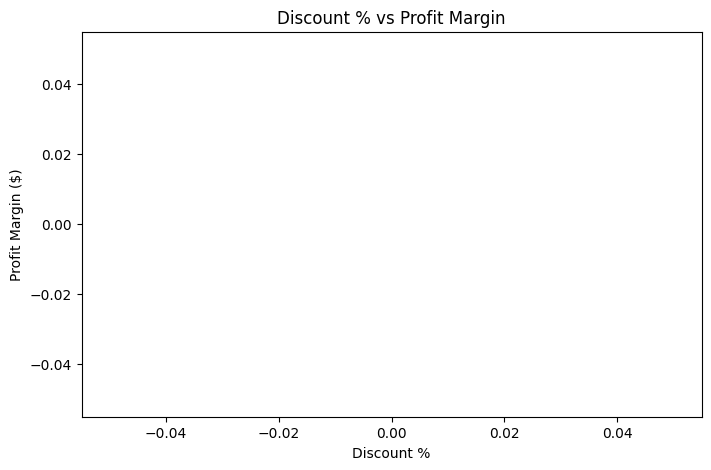

Correlation between Discount % and Profit Margin: nan


In [71]:
# Do higher discounts reduce profits?
import matplotlib.pyplot as plt
import seaborn as sns

# Check column type
print(sales['Discount %'].dtype)

# Convert Discount % to numeric safely
sales['Discount %'] = pd.to_numeric(sales['Discount %'].astype(str).str.replace('%',''), errors='coerce')

# Ensure Profit Margin is numeric
sales['Profit Margin'] = pd.to_numeric(sales['Profit Margin'], errors='coerce')

# Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount %', y='Profit Margin', data=sales)
plt.title("Discount % vs Profit Margin")
plt.xlabel("Discount %")
plt.ylabel("Profit Margin ($)")
plt.show()

# Correlation
correlation = sales['Discount %'].corr(sales['Profit Margin'])
print(f"Correlation between Discount % and Profit Margin: {correlation:.2f}")

State with the highest number of orders:
 State
NSW    3584
Name: count, dtype: int64


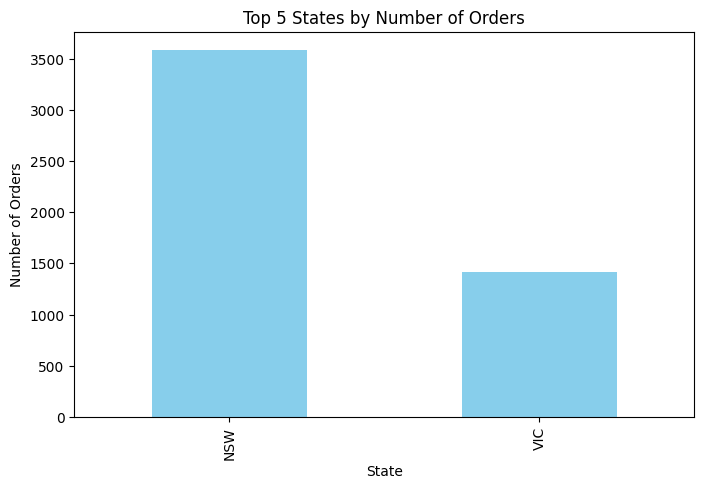

In [72]:
# Which state has the highest number of orders?
# Count orders per state
state_orders = sales['State'].value_counts()

# Top state
top_state = state_orders.head(1)

print("State with the highest number of orders:\n", top_state)

state_orders.head(5).plot(kind='bar', color='skyblue', figsize=(8,5), title='Top 5 States by Number of Orders')
plt.ylabel('Number of Orders')
plt.xlabel('State')
plt.show()

In [73]:
# What is the average discount % across all orders?
# Convert Discount % to numeric safely (if not already)
sales['Discount %'] = pd.to_numeric(sales['Discount %'].astype(str).str.replace('%',''), errors='coerce')

# Calculate average discount %
avg_discount = sales['Discount %'].mean()
print(f"Average discount across all orders: {avg_discount:.2f}%")

Average discount across all orders: nan%


In [74]:
# What is the average total spend per order?
# Ensure Total is numeric
sales['Total'] = pd.to_numeric(sales['Total'], errors='coerce')

# Calculate average total spend per order
avg_total_spend = sales['Total'].mean()
print(f"Average total spend per order: ${avg_total_spend:.2f}")

Average total spend per order: $746.31


Average profit margin by container type:
 Product Container
Small Box     19.668452
Small Pack    16.836970
Jumbo Drum    16.483419
Wrap Bag      16.407018
Medium Box    15.637523
Large Box     11.637730
Name: Profit Margin, dtype: float64


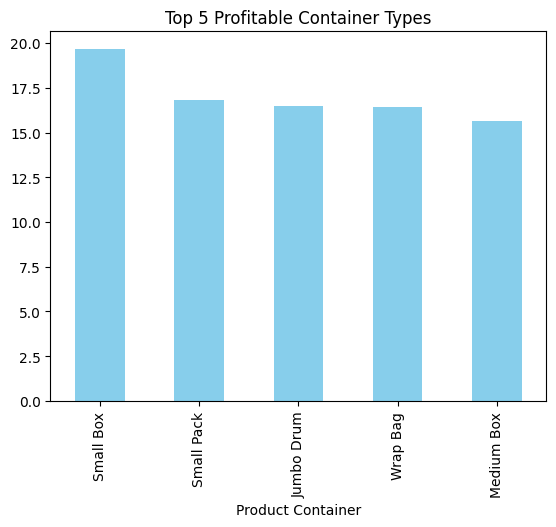

In [75]:
# . Are certain containers (e.g., Small Box, Wrap Bag) more profitable?
# Ensure Profit Margin is numeric
sales['Profit Margin'] = pd.to_numeric(sales['Profit Margin'], errors='coerce')

# Check if 'Product Container' column exists
if 'Product Container' in sales.columns:
    # Calculate average profit by container
    container_profit = sales.groupby('Product Container')['Profit Margin'].mean().sort_values(ascending=False)
    print("Average profit margin by container type:\n", container_profit)

    # Optional: visualize top 5 container types
    container_profit.head(5).plot(kind='bar', color='skyblue', title='Top 5 Profitable Container Types')
else:
    print("The dataset does not have a 'Product Container' column.")